# Task 3: Gaussian pulse vs DRAG pulse

??????????? transmon ?? Gaussian `X` ??? DRAG `X` ???? 1 ??????????? `P0/P1/P2` ?????????? 2 ???? DRAG beta ????????????????? Gaussian ???????????????? Gaussian ? DRAG ????????????

?????????? `|0>` ? `X` ??? `1 - P1(final)`??????? `P2(final)`?

In [1]:
from dataclasses import replace
from pathlib import Path

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

from musiq.pulse.sequence import PulseCompiler
from musiq.workflow import create_model


TASK_DIR = Path(".")
if not (TASK_DIR / "task.yaml").exists():
    TASK_DIR = Path("report/task3_gaussian_drag_comparison")

FIG_DIR = TASK_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

## 图 1：Gaussian 和 DRAG 的波形与三能级布居数

先分别用 `pulse_gaussian.yaml` 和 `pulse_drag.yaml` 创建模型，然后运行。默认门长、sigma、shape 和 DRAG beta 都写在 YAML 里。

In [2]:
cases = []

for shape in ["gaussian", "drag"]:
    pulse_file = "pulse_drag.yaml" if shape == "drag" else "pulse_gaussian.yaml"
    model = create_model(task_config=TASK_DIR / "task.yaml", pulse_config=TASK_DIR / pulse_file)
    # pulse = model.pulse["pulse"] if "pulse" in model.pulse else model.pulse

    model.run_all()

    trajectory = model.runs["solver_0"].result.trajectory
    rho_t = np.asarray(trajectory.density_matrix["snapshots"], dtype=complex)
    populations = np.real(np.diagonal(rho_t, axis1=1, axis2=2))

    solver_run = model.runs["solver_0"]
    pulse_ir = replace(solver_run.artifacts.pulse_ir, t_end_s=solver_run.artifacts.model_spec.time.t_end_s)
    pulse_samples = PulseCompiler.compile(pulse_ir, sample_rate_Hz=1e11)
    xy_key = next(key for key in pulse_samples if key.startswith("XY_"))
    waveform = pulse_samples[xy_key]

    p_final = populations[-1]
    cases.append(
        {
            "shape": shape,
            "extras": model.pulse.extras,
            "times_ns": np.asarray(trajectory.times) * 1e9,
            "populations": populations,
            "waveform_t_ns": waveform["t"] * 1e9,
            "waveform_i": waveform["y"],
            "waveform_q": waveform.get("y_quadrature", np.zeros_like(waveform["y"])),
            "gate_error": 1.0 - float(p_final[1]),
            "leakage": float(p_final[2]),
        }
    )

gaussian, drag = cases
print(f"Gaussian: gate error = {gaussian['gate_error']:.6g}, leakage = {gaussian['leakage']:.6g}")
print(f"DRAG:     gate error = {drag['gate_error']:.6g}, leakage = {drag['leakage']:.6g}")

Gaussian: gate error = 0.0274359, leakage = 0.000405818
DRAG:     gate error = 0.00492398, leakage = 0.000127571


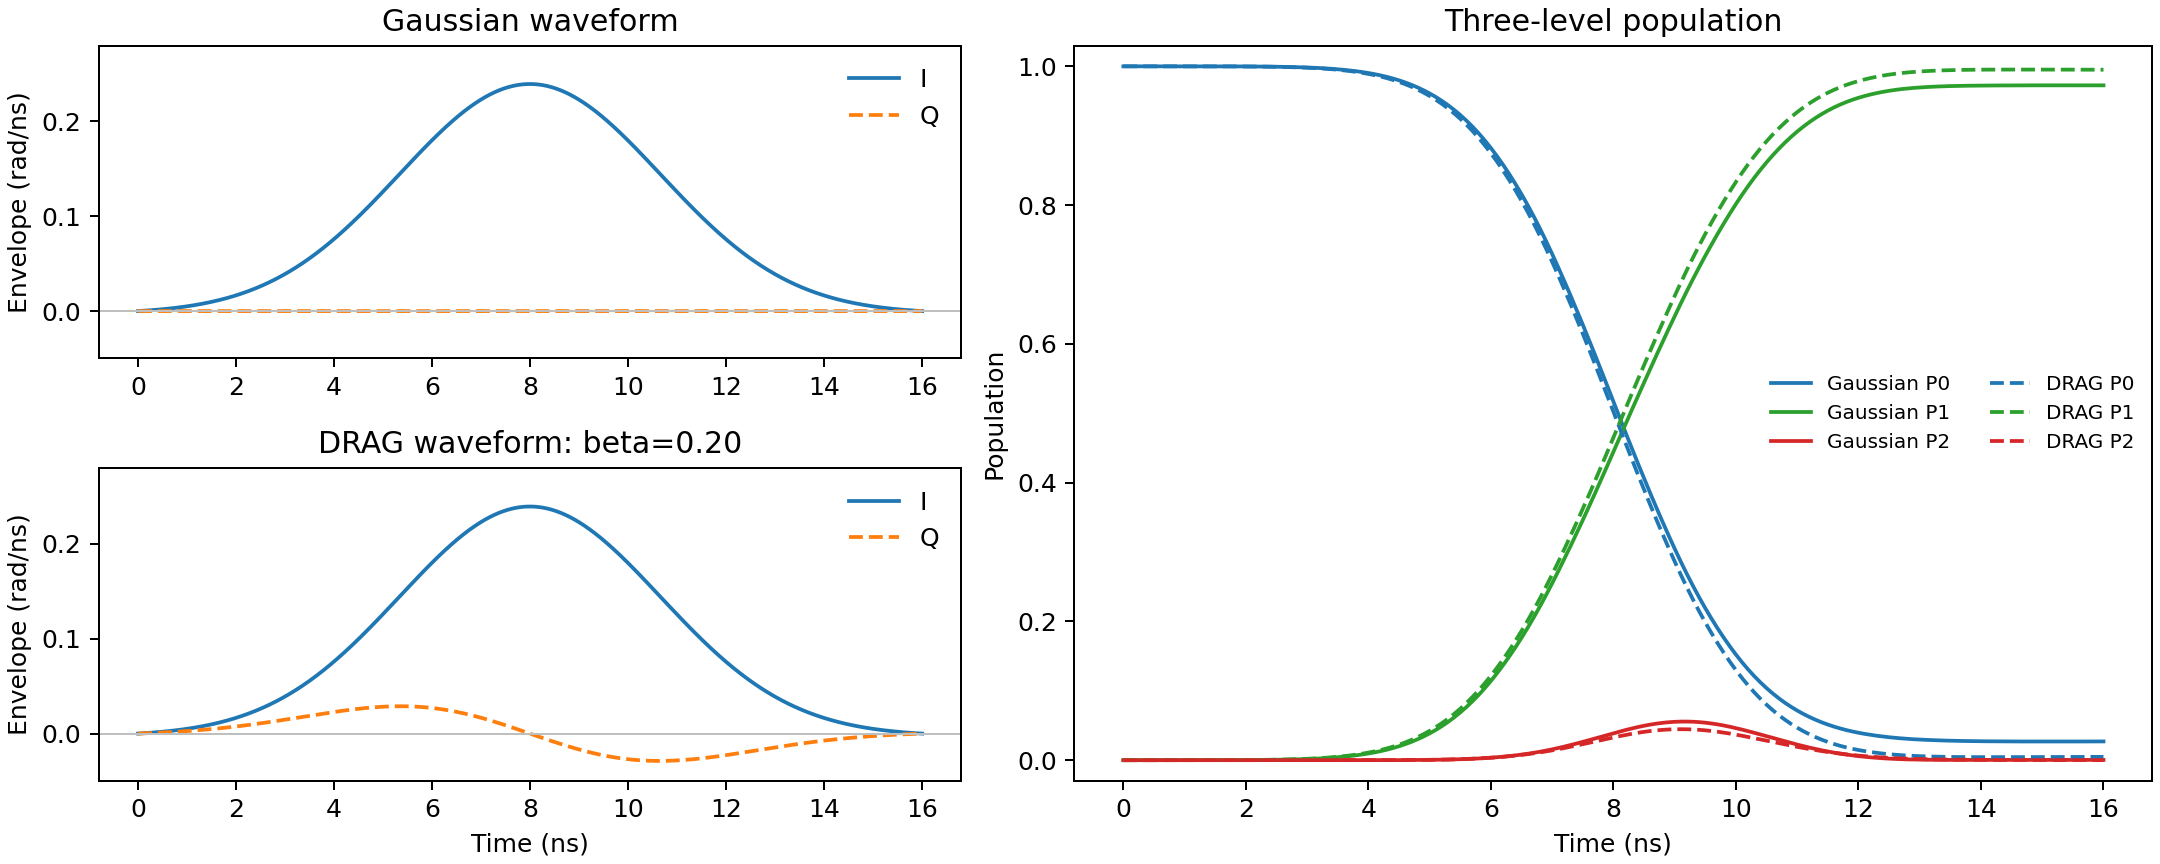

In [3]:
fig = plt.figure(figsize=(12.0, 4.8), constrained_layout=True)
grid = fig.add_gridspec(2, 2, width_ratios=[1.0, 1.25])
ax_gauss = fig.add_subplot(grid[0, 0])
ax_drag = fig.add_subplot(grid[1, 0], sharex=ax_gauss)
ax_pop = fig.add_subplot(grid[:, 1])

ax_gauss.plot(gaussian["waveform_t_ns"], gaussian["waveform_i"] * 1e-9, label="I")
ax_gauss.plot(gaussian["waveform_t_ns"], gaussian["waveform_q"] * 1e-9, "--", label="Q")
ax_gauss.axhline(0.0, color="0.75", linewidth=0.8)
ax_gauss.set_ylim(-0.05, 0.28)
ax_gauss.set_title("Gaussian waveform")
ax_gauss.set_ylabel("Envelope (rad/ns)")
ax_gauss.legend(frameon=False, loc="upper right")

ax_drag.plot(drag["waveform_t_ns"], drag["waveform_i"] * 1e-9, label="I")
ax_drag.plot(drag["waveform_t_ns"], drag["waveform_q"] * 1e-9, "--", label=f"Q")
ax_drag.axhline(0.0, color="0.75", linewidth=0.8)
ax_drag.set_ylim(-0.05, 0.28)
ax_drag.set_title(f"DRAG waveform: beta={drag['extras'].get('single_qubit_drag_beta', 'N/A'):.2f}")
ax_drag.set_xlabel("Time (ns)")
ax_drag.set_ylabel("Envelope (rad/ns)")
ax_drag.legend(frameon=False, loc="upper right")

labels = ["P0", "P1", "P2"]
colors = ["tab:blue", "tab:green", "tab:red"]
for i, (label, color) in enumerate(zip(labels, colors, strict=False)):
    ax_pop.plot(gaussian["times_ns"], gaussian["populations"][:, i], color=color, label=f"Gaussian {label}")
for i, (label, color) in enumerate(zip(labels, colors, strict=False)):
    ax_pop.plot(drag["times_ns"], drag["populations"][:, i], "--", color=color, label=f"DRAG {label}")
ax_pop.set_title("Three-level population")
ax_pop.set_xlabel("Time (ns)")
ax_pop.set_ylabel("Population")
ax_pop.set_ylim(-0.03, 1.03)
ax_pop.legend(frameon=False, ncol=2, fontsize=8)

fig1_path = FIG_DIR / "waveform_population.png"
fig.savefig(fig1_path, dpi=180)
plt.close(fig)
display(Image(filename=str(fig1_path)))

## 图 2：扫描 beta 和门时间

下面保持同样的流程，只在循环里改变需要扫描的 `single_qubit_drag_beta` 或 `gate_duration_ns`，每次运行后记录 `1 - P1(final)` 和 `P2(final)`。

In [4]:
beta_rows = []
for beta in np.linspace(-0.8, 0.8, 25):
    model = create_model(task_config=TASK_DIR / "task.yaml", pulse_config=TASK_DIR / "pulse_drag.yaml")
    model.pulse.extras["single_qubit_drag_beta"] = float(beta)
    model.run_all()

    trajectory = model.runs["solver_0"].result.trajectory
    rho_end = np.asarray(trajectory.density_matrix["snapshots"][-1], dtype=complex)
    p_final = np.real(np.diag(rho_end))
    beta_rows.append({"beta": float(beta), "gate_error": 1.0 - float(p_final[1]), "leakage": float(p_final[2])})

best_beta = min(beta_rows, key=lambda row: row["gate_error"])["beta"]
print(f"best beta by gate error = {best_beta:.3f}")

gate_rows = []
for gate_time_ns in np.linspace(10.0, 30.0, 21):
    row = {"gate_time_ns": float(gate_time_ns)}
    for shape in ["gaussian", "drag"]:
        pulse_file = "pulse_drag.yaml" if shape == "drag" else "pulse_gaussian.yaml"
        model = create_model(task_config=TASK_DIR / "task.yaml", pulse_config=TASK_DIR / pulse_file)
        model.pulse.extras["gate_duration_ns"] = float(gate_time_ns)
        if shape == "drag":
            model.pulse.extras["single_qubit_drag_beta"] = best_beta
        model.run_all()

        trajectory = model.runs["solver_0"].result.trajectory
        rho_end = np.asarray(trajectory.density_matrix["snapshots"][-1], dtype=complex)
        p_final = np.real(np.diag(rho_end))
        row[f"{shape}_error"] = 1.0 - float(p_final[1])
        row[f"{shape}_leakage"] = float(p_final[2])
    gate_rows.append(row)

best beta by gate error = 0.133


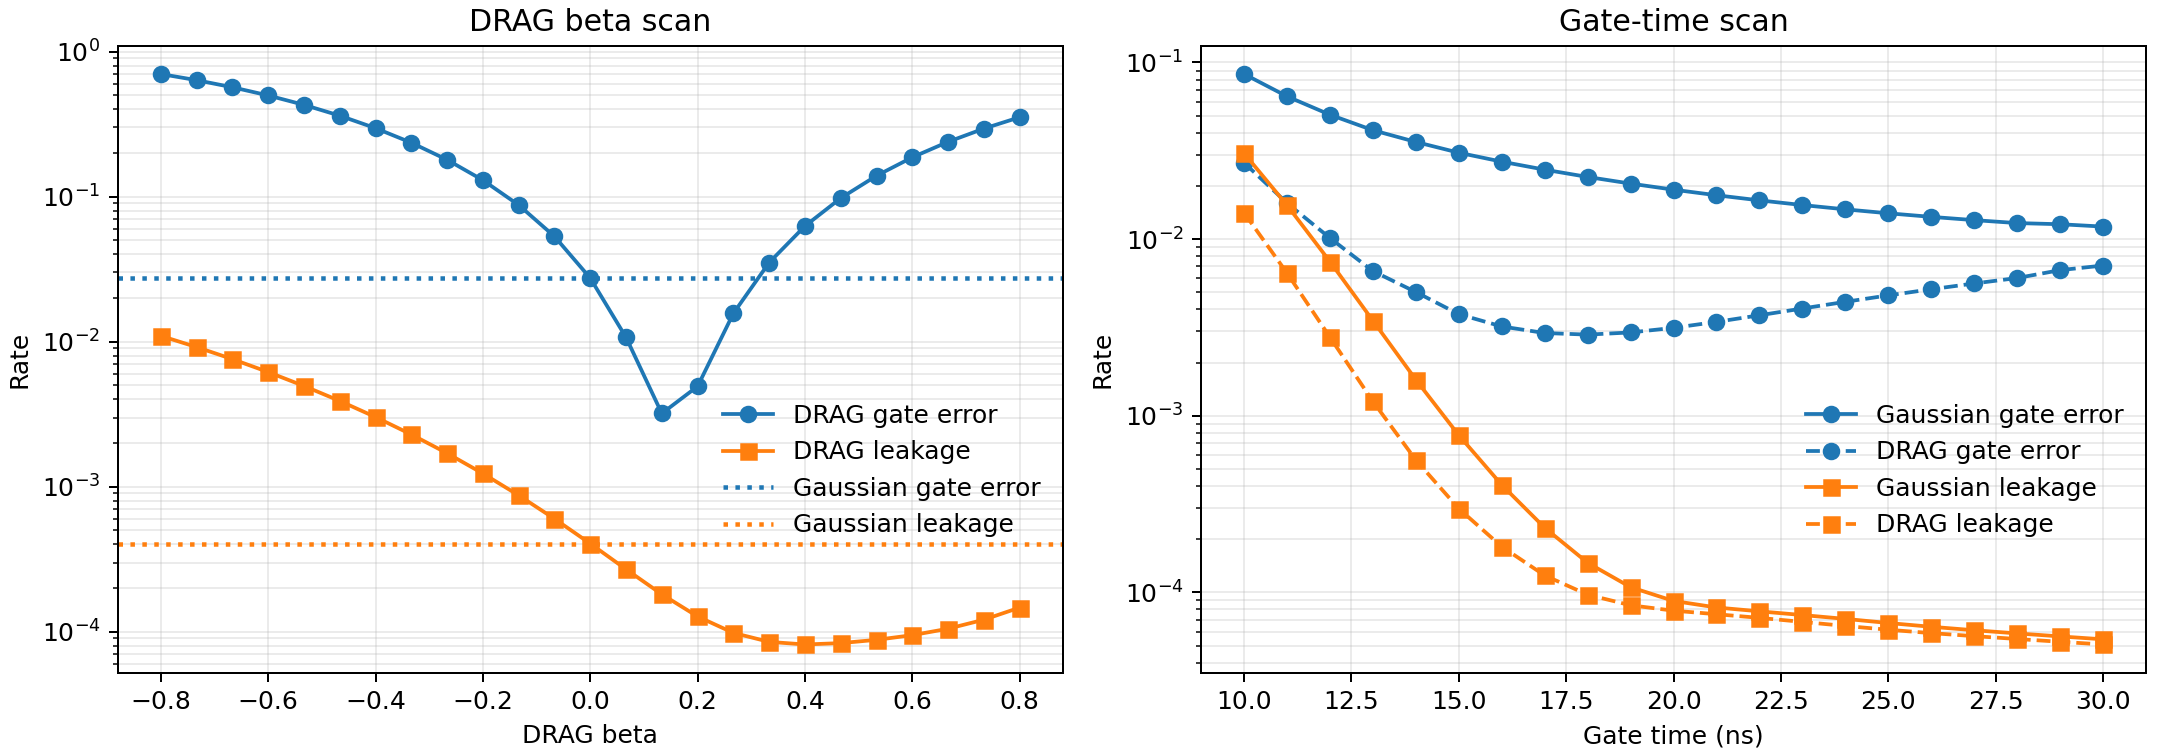

In [5]:
beta = np.asarray([row["beta"] for row in beta_rows])
beta_error = np.asarray([row["gate_error"] for row in beta_rows])
beta_leakage = np.asarray([row["leakage"] for row in beta_rows])

gate_time = np.asarray([row["gate_time_ns"] for row in gate_rows])
gaussian_error = np.asarray([row["gaussian_error"] for row in gate_rows])
drag_error = np.asarray([row["drag_error"] for row in gate_rows])
gaussian_leakage = np.asarray([row["gaussian_leakage"] for row in gate_rows])
drag_leakage = np.asarray([row["drag_leakage"] for row in gate_rows])

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True)

ax = axes[0]
ax.semilogy(beta, beta_error, "o-", label="DRAG gate error")
ax.semilogy(beta, beta_leakage, "s-", label="DRAG leakage")
ax.axhline(gaussian["gate_error"], color="tab:blue", linestyle=":", linewidth=1.8, label="Gaussian gate error")
ax.axhline(gaussian["leakage"], color="tab:orange", linestyle=":", linewidth=1.8, label="Gaussian leakage")
ax.set_title("DRAG beta scan")
ax.set_xlabel("DRAG beta")
ax.set_ylabel("Rate")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False, loc=(0.63,0.2))

ax = axes[1]
ax.semilogy(gate_time, gaussian_error, "o-", color="tab:blue", label="Gaussian gate error")
ax.semilogy(gate_time, drag_error, "o--", color="tab:blue", label="DRAG gate error")
ax.semilogy(gate_time, gaussian_leakage, "s-", color="tab:orange", label="Gaussian leakage")
ax.semilogy(gate_time, drag_leakage, "s--", color="tab:orange", label="DRAG leakage")
ax.set_title("Gate-time scan")
ax.set_xlabel("Gate time (ns)")
ax.set_ylabel("Rate")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False, loc=(0.63,0.2))

fig2_path = FIG_DIR / "beta_gate_time_scan.png"
fig.savefig(fig2_path, dpi=180)
plt.close(fig)
display(Image(filename=str(fig2_path)))